In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import warnings

warnings.filterwarnings('ignore')

class SurvivalPredictor:
    
    def __init__(self, file_path):
        
        self.df = pd.read_csv(file_path)
        
        self.df.columns = [col.lower() for col in self.df.columns]
        
        self.cleaned_df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        
        print(f"Data loaded successfully. Initial records: {len(self.df)}")
        
    
    def clean_and_prepare_data(self):
    
        df = self.df.copy()

        df.isnull().sum()

        df.dropna(inplace=True)

        df['sex'] = df['sex'].map({'male': 0, 'female': 1})

        df = pd.get_dummies(df, columns=['station'], drop_first=True)

        self.cleaned_df = df
    
        final_count = len(self.cleaned_df)
        
        print(f"\n1. Data Cleaning Complete. Final records after dropping missing rows: {final_count}")
        
        return final_count

    
    def explore_and_select_features(self):
    
        df = self.cleaned_df
    
        print("\n Basic Data Exploration:")
    
        print(df.head())
    
        print(df.describe().T)
    
        print(df.nunique())

        print(f"Total records in Cleaned DataFrame (len): {len(df)}")

        print(f"shape : {df.shape}")

        print(df['pclass'].unique().tolist())

        most_frequent_station = self.df['station'].mode()[0]
        
        print(f"\n2. The train picked most passengers from station: {most_frequent_station}")

        variables_not_selected_for_modeling = []
        
        print(f"\n3. Variables I will NOT select : {variables_not_selected_for_modeling}")

        print("All variables in the dataset are meaningful and used for modeling.")

    
    def treat_outliers(self, column, threshold=3):
        
        df = self.cleaned_df
    
        if column in ['fare', 'age']:
            z = np.abs((df[column] - df[column].mean()) / df[column].std())
            outliers_count = len(df[z > threshold])

            if outliers_count > 0:
                upper_bound = df[column].mean() + threshold * df[column].std()
                lower_bound = df[column].mean() - threshold * df[column].std()

                df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
                df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])

                self.cleaned_df = df
                print(f"\n4. Outliers detected in {column}: {outliers_count} records. Treated by capping.")
            else:
                print(f"\n4. No significant outliers found in {column}.")

    
    def partition_data(self, test_size=0.3, random_state=12345):
    
        df = self.cleaned_df

        X = df.drop('survived', axis=1)
        y = df['survived']

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split( X, y, test_size=test_size, random_state=random_state)
        
        print(f"\n5. Data Partitioning Complete (random_state={random_state}).")
        
        print(f" Training set size: {len(self.X_train)}")
        
        print(f" Testing set size: {len(self.X_test)}")


    def build_best_knn_model(self):
    
        X_train, X_test, y_train, y_test = self.X_train, self.X_test, self.y_train, self.y_test
        
        k_range = range(1, 16)
        training_accuracy = []
        test_accuracy = []

        for k in k_range:
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train, y_train)
            training_accuracy.append(knn.score(X_train, y_train))
            test_accuracy.append(knn.score(X_test, y_test))
       
        best_k = np.argmax(test_accuracy) + 1 
        
        best_knn = KNeighborsClassifier(n_neighbors=best_k)
        best_knn.fit(X_train, y_train)

        train_score = best_knn.score(X_train, y_train)
        test_score = best_knn.score(X_test, y_test)

        print(f" KNN plot:")

        plt.figure(figsize=(10, 4))
        plt.plot(k_range, training_accuracy, label="KNN Training Accuracy")
        plt.plot(k_range, test_accuracy, label="KNN Test Accuracy")
        plt.title("KNN Accuracy vs. Number of Neighbors (k)")
        plt.xlabel("Number of Neighbors (k)")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"\n6. Best KNN Model:")
        print(f" Best k chosen: {best_k}")
        print(f" Training Set Accuracy: {round(train_score, 4)}")
        print(f" Testing Set Accuracy: {round(test_score, 4)}")
        
        return test_score


    def build_logistic_regression_model(self):
    
        X_train, X_test, y_train, y_test = self.X_train, self.X_test, self.y_train, self.y_test

        logreg = LogisticRegression(random_state=12345, max_iter=500)
    
        logreg.fit(X_train, y_train)

        train_score = logreg.score(X_train, y_train)
        test_score = logreg.score(X_test, y_test)

        print(f"\n7. Logistic Regression Model:")
        print(f" Training Set Accuracy: {round(train_score, 4)}")
        print(f" Testing Set Accuracy: {round(test_score, 4)}")
        
        return test_score


    def build_decision_tree_model(self):
        
        X_train, X_test, y_train, y_test = self.X_train, self.X_test, self.y_train, self.y_test
        
        tree_depth_range = range(1, 11)
        test_accuracy = []

        for td in tree_depth_range:
            treeMod = DecisionTreeClassifier(max_depth=td, random_state=12345)
            treeMod.fit(X_train, y_train)
            test_accuracy.append(treeMod.score(X_test, y_test))                                  

        best_depth = np.argmax(test_accuracy) + 1
        
        best_treeMod = DecisionTreeClassifier(max_depth=best_depth, random_state=12345)
        best_treeMod.fit(X_train, y_train)
    
        train_score = best_treeMod.score(X_train, y_train)
        test_score = best_treeMod.score(X_test, y_test)
        
        print(f"\n8. Decision Tree Model results:")
        print(f" Ideal Tree Depth chosen: {best_depth}")
        print(f" Training Set Accuracy: {round(train_score, 4)}")
        print(f" Testing Set Accuracy: {round(test_score, 4)}")


        print(f"\n Decision Tree : (Depth 3 for readability)")
        plt.figure(figsize=(15, 10))
        simple_tree = DecisionTreeClassifier(max_depth=3, random_state=12345).fit(X_train, y_train)
        tree.plot_tree(simple_tree, 
                       feature_names=X_train.columns.tolist(), 
                       class_names=['Died', 'Survived'], 
                       filled=True, 
                       fontsize=9)
        plt.title('Decision Tree Visualization (Max Depth=3)')
        plt.show()
        
        return test_score


    def show_interesting_graphs(self):

        df = self.cleaned_df.copy()
        print("\n Interesting Graphs to Describe the Original Data:")
        
        plt.figure(figsize=(8, 5))
        sns.barplot(x='sex', y='survived', data=self.df, errorbar=None, palette='magma')
        plt.title('Survival Rate by Gender')
        plt.ylabel('Survival Rate')
        plt.xticks([0, 1], ['Male', 'Female'])
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        sns.barplot(x='pclass', y='survived', data=self.df, errorbar=None, palette='magma')
        plt.title('Survival Rate by Passenger Class')
        plt.xlabel('Passenger Class (1=1st, 2=2nd, 3=3rd)')
        plt.ylabel('Survival Rate')
        plt.tight_layout()
        plt.show()
    
        plot_df = self.df.copy()
        plot_df.dropna(inplace=True)
        plot_df['survival'] = plot_df['survived'].map({0: 'Died', 1: 'Survived'})
        plt.figure(figsize=(10, 6))
        sns.histplot(data=plot_df, x='age', hue='survival', kde=True, bins=30, palette='viridis')
        plt.title('Age Distribution by Survival Status')
        plt.legend(labels=['Died', 'Survived'])
        plt.tight_layout()
        plt.show()

        df['family_size'] = df['sibsp'] + df['parch'] + 1 
        plt.figure(figsize=(10, 6))
        sns.barplot(x='family_size', y='survived', data=df, errorbar=None, palette='magma')
        plt.title('Survival Rate by Total Family Size')
        plt.xlabel('Family Size (Siblings/Spouses + Parents/Children + Self)')
        plt.ylabel('Survival Rate')
        plt.tight_layout()
        plt.show()


--- STARTING PROJECT EXECUTION ---
Data loaded successfully. Initial records: 891

1. Data Cleaning Complete. Final records after dropping missing rows: 712

 Basic Data Exploration:
   survived  pclass  sex   age  sibsp  parch     fare  station_Q  station_S
0         0       3    0  22.0      1      0   7.2500      False       True
1         1       1    1  38.0      1      0  71.2833      False      False
2         1       3    1  26.0      0      0   7.9250      False       True
3         1       1    1  35.0      1      0  53.1000      False       True
4         0       3    0  35.0      0      0   8.0500      False       True
          count       mean        std   min    25%       50%   75%       max
survived  712.0   0.404494   0.491139  0.00   0.00   0.00000   1.0    1.0000
pclass    712.0   2.240169   0.836854  1.00   1.00   2.00000   3.0    3.0000
sex       712.0   0.363764   0.481420  0.00   0.00   0.00000   1.0    1.0000
age       712.0  29.642093  14.492933  0.42  20.00  

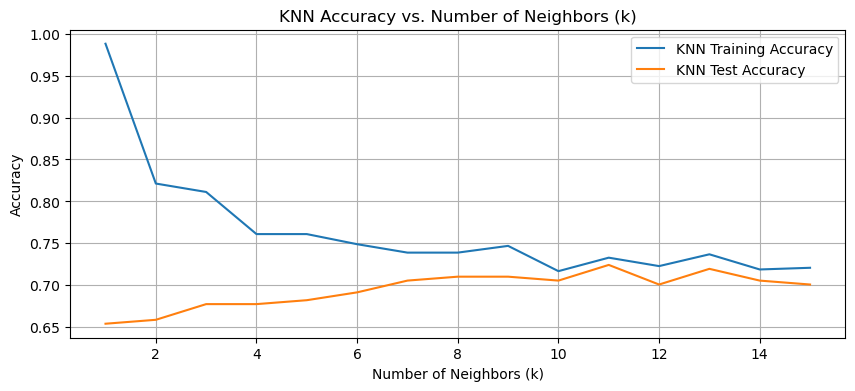


6. Best KNN Model:
 Best k chosen: 11
 Training Set Accuracy: 0.7329
 Testing Set Accuracy: 0.7243

7. Logistic Regression Model:
 Training Set Accuracy: 0.7831
 Testing Set Accuracy: 0.8271

8. Decision Tree Model results:
 Ideal Tree Depth chosen: 6
 Training Set Accuracy: 0.8715
 Testing Set Accuracy: 0.8458

 Decision Tree : (Depth 3 for readability)


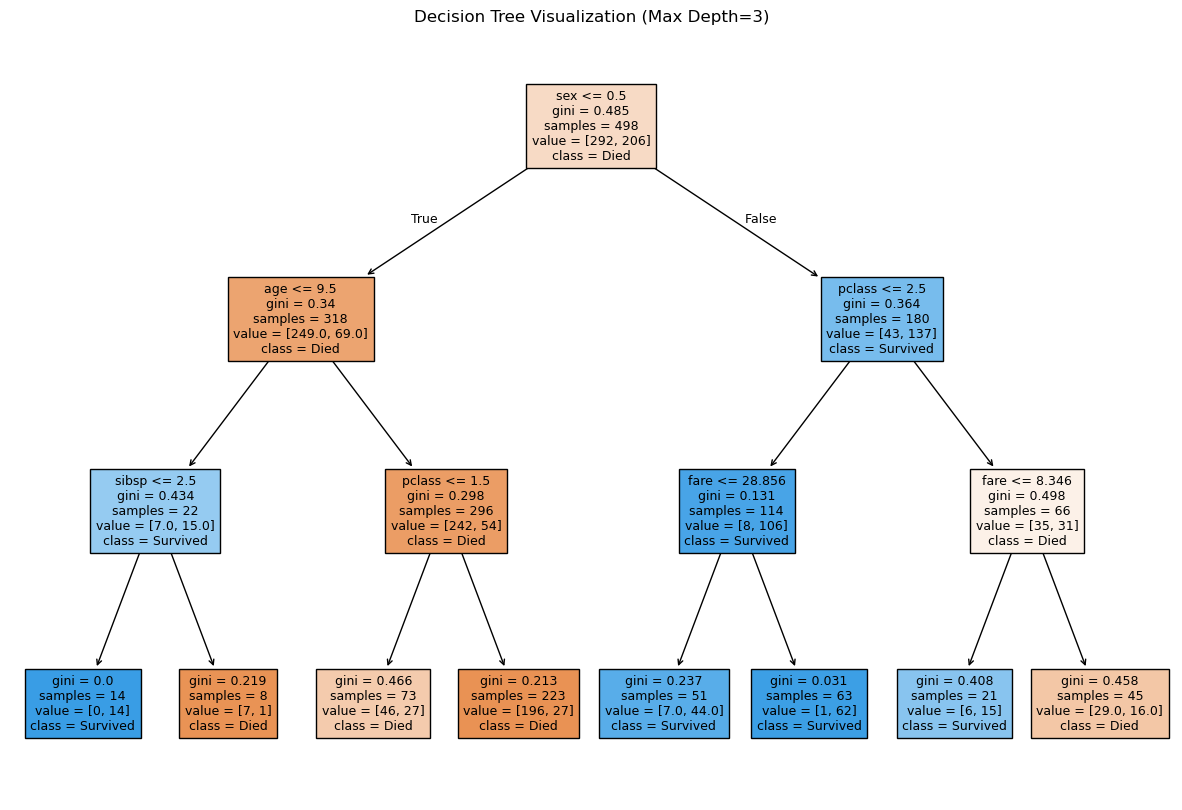


9. Model Comparison and Selection
| Model               |   Test Accuracy |
|:--------------------|----------------:|
| Decision Tree       |          0.8458 |
| Logistic Regression |          0.8271 |
| KNN                 |          0.7243 |

Based on Test Accuracy, the best model is the Decision Tree, with an accuracy of 0.8458.

Explanation for Q9 (Best Model):
The Test Accuracy is the definitive metric for choosing the best model, as it shows how well the model generalizes to new, unseen data.
The Decision Tree achieved the highest accuracy, making it the top performing model in this comparison.

10. Data Visualization

 Interesting Graphs to Describe the Original Data:


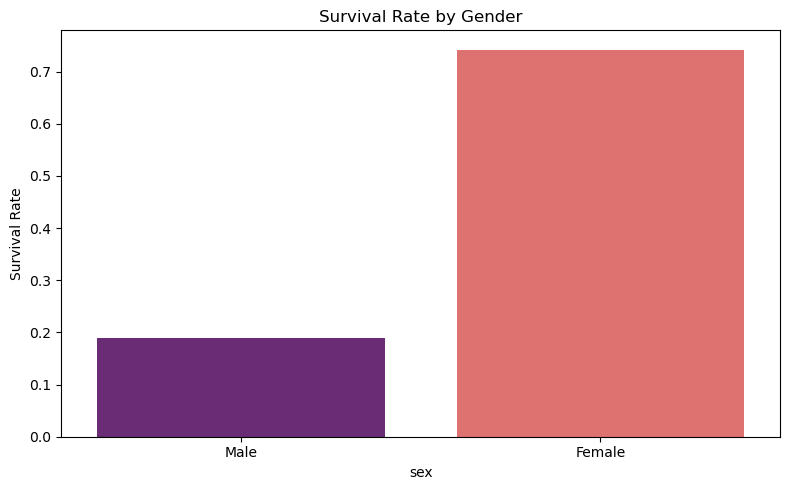

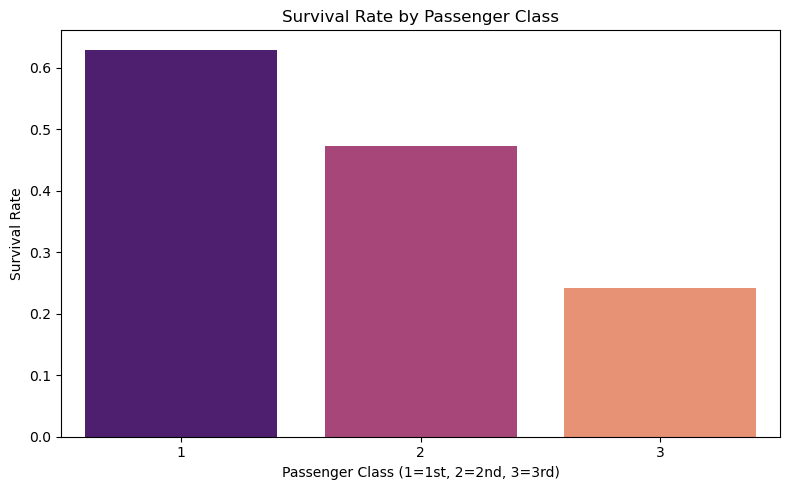

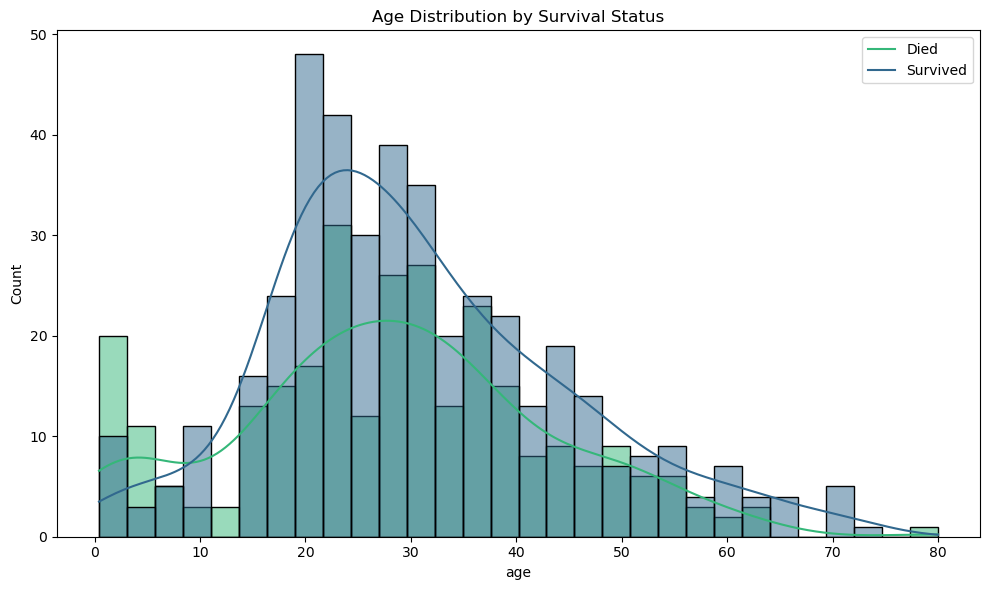

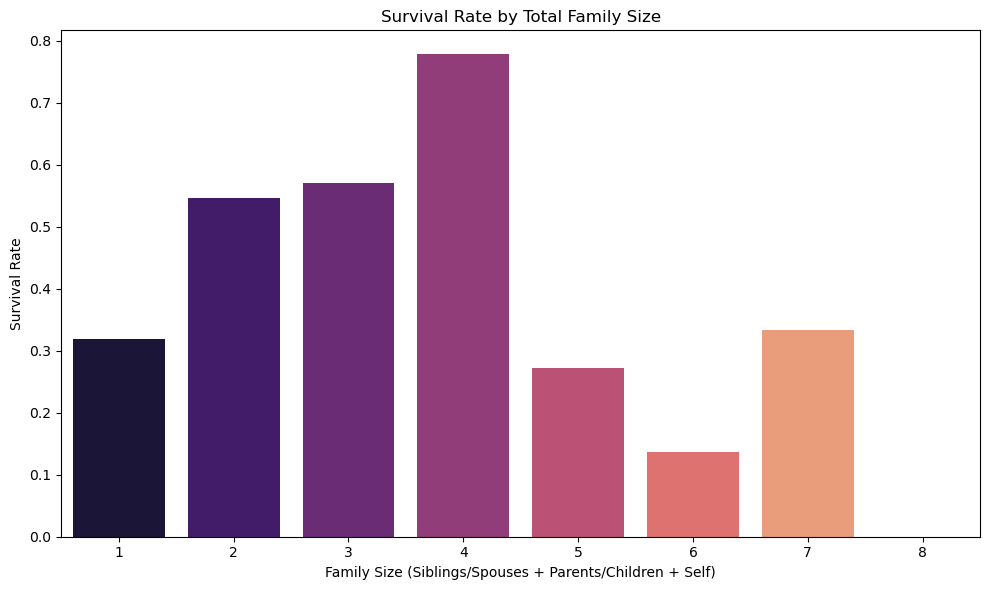

In [43]:
print("\n--- STARTING PROJECT EXECUTION ---")
FILE_NAME = 'TrainData.csv'
train_predictor = SurvivalPredictor(FILE_NAME)

cleaned_rows = train_predictor.clean_and_prepare_data()

train_predictor.explore_and_select_features()

train_predictor.treat_outliers('fare')
train_predictor.treat_outliers('age')

train_predictor.partition_data(test_size=0.3, random_state=12345)
print("\n" + "="*50)
print("           MODEL TRAINING RESULTS")
print("="*50)

knn_accuracy = train_predictor.build_best_knn_model()

logreg_accuracy = train_predictor.build_logistic_regression_model()

dt_accuracy = train_predictor.build_decision_tree_model()

comparison_df = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Decision Tree'],
    'Test Accuracy': [knn_accuracy, logreg_accuracy, dt_accuracy]
})
comparison_df.sort_values(by='Test Accuracy', ascending=False, inplace=True)

print("\n" + "="*50)
print("9. Model Comparison and Selection")
print("="*50)
print(comparison_df.round(4).to_markdown(index=False))

best_model = comparison_df.iloc[0]
print(f"\nBased on Test Accuracy, the best model is the {best_model['Model']}, with an accuracy of {round(best_model['Test Accuracy'], 4)}.")
print("\nExplanation for Q9 (Best Model):")
print("The Test Accuracy is the definitive metric for choosing the best model, as it shows how well the model generalizes to new, unseen data.")
print("The Decision Tree achieved the highest accuracy, making it the top performing model in this comparison.")

print("\n" + "="*50)
print("10. Data Visualization")
print("="*50)
train_predictor.show_interesting_graphs()
